In [10]:
import xgboost as xgb
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc, log_loss
import matplotlib.pyplot as plt
from datetime import datetime

Accuracy: 0.9466830234972162
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      9716
           1       0.80      0.48      0.60       881

    accuracy                           0.95     10597
   macro avg       0.88      0.74      0.79     10597
weighted avg       0.94      0.95      0.94     10597

Log Loss: 0.14943689182765865
AUC: 0.9335950880137798


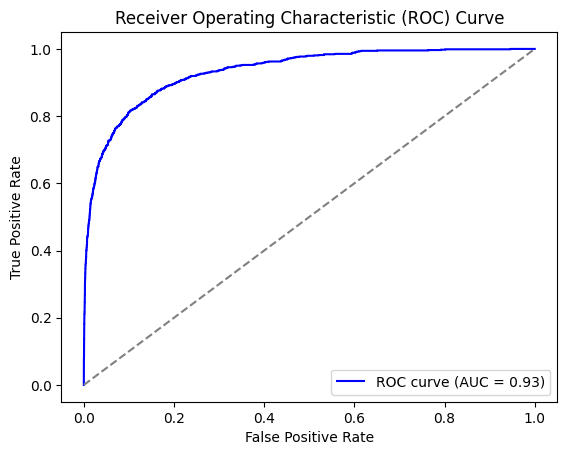

In [11]:
# Load the data
data = pd.read_csv('hoteles-entrena-limpio-normalizado.csv')

# Define features (X) and target (y)
X = data.drop(columns=['children'])  # Dropping the target column
y = data['children']

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the XGBoost classifier
model = xgb.XGBClassifier(eval_metric='logloss')

# Train the model
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]  # Probabilidad para la clase positiva

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
logloss = log_loss(y_test, y_pred_proba)

# ROC Curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Display results
print(f'Accuracy: {accuracy}')
print('Classification Report:')
print(report)
print(f'Log Loss: {logloss}')
print(f'AUC: {roc_auc}')

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

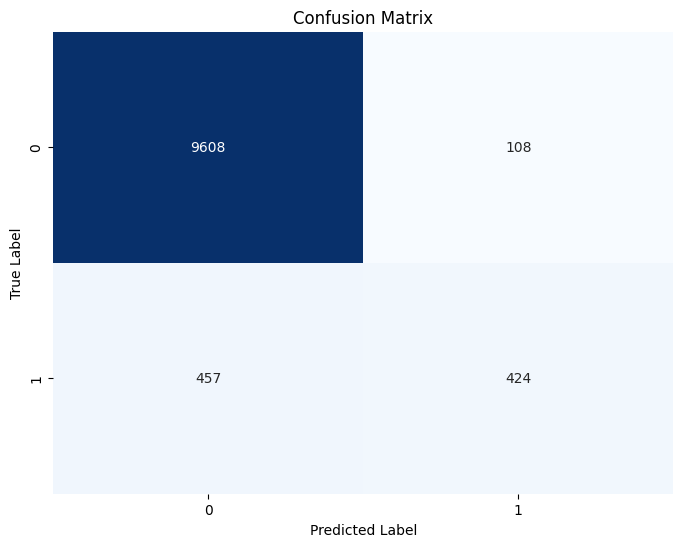

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predecimos nuevamente para asegurarnos de tener los resultados actualizados
y_pred = model.predict(X_test)

# Generamos la matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred)

# Visualizamos la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

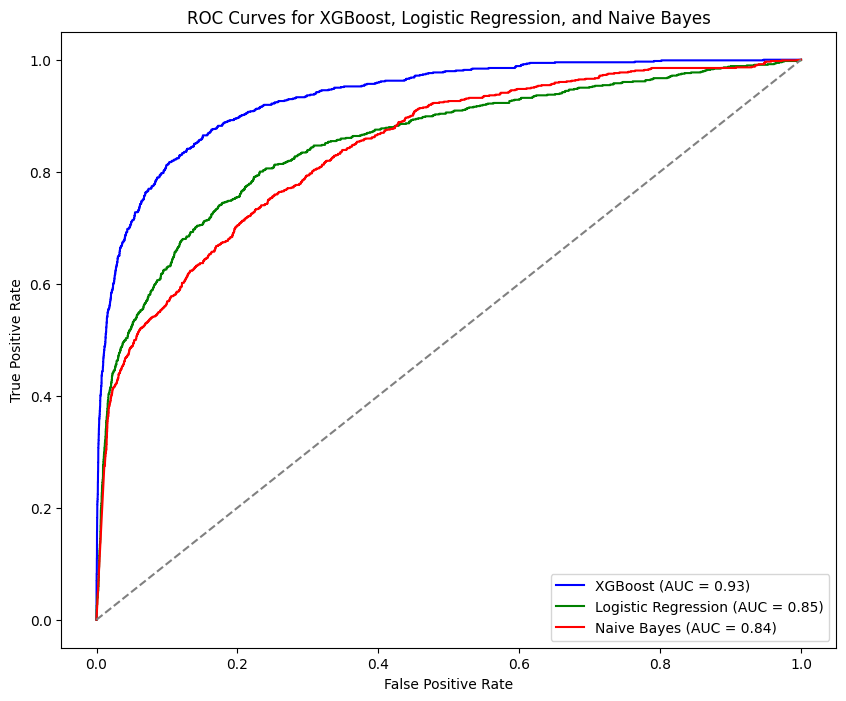

XGBoost Results:
Accuracy: 0.9466830234972162
Log Loss: 0.14943689182765865
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      9716
           1       0.80      0.48      0.60       881

    accuracy                           0.95     10597
   macro avg       0.88      0.74      0.79     10597
weighted avg       0.94      0.95      0.94     10597


Logistic Regression Results:
Accuracy: 0.9326224403132962
Log Loss: 0.20385119584220468
              precision    recall  f1-score   support

           0       0.94      0.99      0.96      9716
           1       0.70      0.33      0.45       881

    accuracy                           0.93     10597
   macro avg       0.82      0.66      0.71     10597
weighted avg       0.92      0.93      0.92     10597


Naive Bayes Results:
Accuracy: 0.6251769368689252
Log Loss: 1.9548265842656536
              precision    recall  f1-score   support

           0       0.98      0.60      0.75   

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_curve, auc, log_loss, accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

# Definimos las características y la variable objetivo
X = data.drop(columns=['children'])
y = data['children']

# Dividimos el conjunto de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modelo XGBoost
xgb_model = xgb.XGBClassifier(eval_metric='logloss')
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

# Modelo de Regresión Logística
lr_model = LogisticRegression(max_iter=2000)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
y_pred_proba_lr = lr_model.predict_proba(X_test)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

# Modelo Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)
y_pred_proba_nb = nb_model.predict_proba(X_test)[:, 1]
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_pred_proba_nb)
roc_auc_nb = auc(fpr_nb, tpr_nb)

# Plot de las curvas ROC
plt.figure(figsize=(10, 8))
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_xgb:.2f})', color='blue')
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})', color='green')
plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUC = {roc_auc_nb:.2f})', color='red')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for XGBoost, Logistic Regression, and Naive Bayes')
plt.legend(loc="lower right")
plt.show()

# Imprimimos los resultados de cada modelo
print("XGBoost Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb)}")
print(f"Log Loss: {log_loss(y_test, y_pred_proba_xgb)}")
print(classification_report(y_test, y_pred_xgb))

print("\nLogistic Regression Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr)}")
print(f"Log Loss: {log_loss(y_test, y_pred_proba_lr)}")
print(classification_report(y_test, y_pred_lr))

print("\nNaive Bayes Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_nb)}")
print(f"Log Loss: {log_loss(y_test, y_pred_proba_nb)}")
print(classification_report(y_test, y_pred_nb))

In [15]:
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score
import numpy as np

# Configuración de la validación cruzada estratificada y regularización L2
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Configuración del modelo con regularización L2
model = xgb.XGBClassifier(eval_metric='logloss', reg_lambda=1.0)

# Listas para almacenar las métricas de cada fold
accuracy_scores = []
log_losses = []
auc_scores = []

# Validación cruzada
for train_index, val_index in kf.split(X, y):
    X_train_fold, X_val_fold = X.iloc[train_index], X.iloc[val_index]
    y_train_fold, y_val_fold = y.iloc[train_index], y.iloc[val_index]
    
    # Entrenamiento del modelo en el fold actual
    model.fit(X_train_fold, y_train_fold)
    
    # Predicciones en el conjunto de validación del fold actual
    y_pred_fold = model.predict(X_val_fold)
    y_pred_proba_fold = model.predict_proba(X_val_fold)[:, 1]
    
    # Calcular las métricas
    accuracy_scores.append(accuracy_score(y_val_fold, y_pred_fold))
    log_losses.append(log_loss(y_val_fold, y_pred_proba_fold))
    auc_scores.append(roc_auc_score(y_val_fold, y_pred_proba_fold))

# Imprimimos las métricas promedio
print(f"Average Accuracy: {np.mean(accuracy_scores):.4f}")
print(f"Average Log Loss: {np.mean(log_losses):.4f}")
print(f"Average AUC: {np.mean(auc_scores):.4f}")

Average Accuracy: 0.9446
Average Log Loss: 0.1567
Average AUC: 0.9226


In [17]:
# Cargamos el archivo de prueba
test_data = pd.read_csv('hoteles-prueba-limpio-normalizado.csv')

# Extraemos la columna "id" y la almacenamos para el archivo final
test_ids = test_data['id']
X_test_data = test_data.drop(columns=['id'])  # Eliminamos "id" para las predicciones

# Realizamos las predicciones de probabilidad con el modelo entrenado
y_pred_proba_test = xgb_model.predict_proba(X_test_data)[:, 1]  # Probabilidad de clase 1

# Creamos un DataFrame con los resultados para Kaggle
kaggle_submission = pd.DataFrame({
    'id': test_ids,
    'prob': y_pred_proba_test  # Agregamos la probabilidad predicha
})

# Generamos un nombre de archivo con timestamp
timestamp = datetime.now().strftime("%Y_%m_%d_%H_%M")
file_name = f'kaggle_submission_{timestamp}.csv'

# Guardamos el archivo en formato CSV para cargarlo en Kaggle
kaggle_submission.to_csv(file_name, index=False)

print(f"Archivo '{file_name}' creado con éxito para Kaggle.")

Archivo 'kaggle_submission_2024_10_13_01_46.csv' creado con éxito para Kaggle.


In [16]:
from sklearn.model_selection import GridSearchCV

# Definimos los parámetros a explorar en la búsqueda en rejilla
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'n_estimators': [100, 200, 300],
    'gamma': [0, 0.1, 0.2],
    'reg_lambda': [0.5, 1.0, 1.5]
}

# Configuramos GridSearchCV con validación cruzada estratificada
grid_search = GridSearchCV(
    estimator=xgb.XGBClassifier(eval_metric='logloss', use_label_encoder=False),
    param_grid=param_grid,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    verbose=1,
    n_jobs=-1
)

# Ejecutamos la búsqueda en rejilla
grid_search.fit(X, y)

# Mejor modelo y mejores parámetros
best_model = grid_search.best_estimator_
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("Mejores hiperparámetros encontrados:")
print(best_params)
print(f"Mejor AUC en validación cruzada: {best_score:.4f}")

Fitting 5 folds for each of 6561 candidates, totalling 32805 fits


c:\Users\Javier_Castillo\.conda\envs\arquitectura\Lib\site-packages\xgboost\core.py:158: UserWarning: [01:44:42] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Mejores hiperparámetros encontrados:
{'colsample_bytree': 0.8, 'gamma': 0.1, 'learning_rate': 0.1, 'max_depth': 7, 'min_child_weight': 5, 'n_estimators': 300, 'reg_lambda': 1.0, 'subsample': 1.0}
Mejor AUC en validación cruzada: 0.9275


In [18]:
# Entrenamos el modelo final con los mejores hiperparámetros encontrados
best_model = xgb.XGBClassifier(
    colsample_bytree=0.8,
    gamma=0.1,
    learning_rate=0.1,
    max_depth=7,
    min_child_weight=5,
    n_estimators=300,
    reg_lambda=1.0,
    subsample=1.0,
    eval_metric='logloss'
)

# Entrenamos el modelo en todos los datos de entrenamiento
best_model.fit(X, y)

# Evaluación en el conjunto de prueba original
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]
accuracy = accuracy_score(y_test, y_pred)
logloss = log_loss(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

print("Resultados del modelo optimizado en el conjunto de prueba:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Log Loss: {logloss:.4f}")
print(f"AUC: {auc:.4f}")
print(classification_report(y_test, y_pred))


Resultados del modelo optimizado en el conjunto de prueba:
Accuracy: 0.9763
Log Loss: 0.0713
AUC: 0.9931
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      9716
           1       0.97      0.74      0.84       881

    accuracy                           0.98     10597
   macro avg       0.97      0.87      0.91     10597
weighted avg       0.98      0.98      0.97     10597



In [19]:

# Realizamos predicciones en el conjunto de datos para Kaggle
test_data = pd.read_csv('hoteles-prueba-limpio-normalizado.csv')
test_ids = test_data['id']
X_test_data = test_data.drop(columns=['id'])

# Generamos las probabilidades de predicción
y_pred_proba_test = best_model.predict_proba(X_test_data)[:, 1]

# Guardamos el archivo con el timestamp
from datetime import datetime
timestamp = datetime.now().strftime("%Y_%m_%d_%H_%M")
file_name = f'kaggle_submission_{timestamp}.csv'
kaggle_submission = pd.DataFrame({'id': test_ids, 'prob': y_pred_proba_test})
kaggle_submission.to_csv(file_name, index=False)

print(f"Archivo '{file_name}' creado con éxito para Kaggle.")

Archivo 'kaggle_submission_2024_10_13_01_49.csv' creado con éxito para Kaggle.


# Segundo intento regresión logística

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score, classification_report
from sklearn.model_selection import StratifiedKFold

# Configuramos la rejilla de hiperparámetros para ElasticNet
param_grid = {
    'C': [0.01, 0.1, 1, 10],               # Controla la regularización; menor valor significa mayor regularización
    'l1_ratio': [0.2, 0.5, 0.8],           # Proporción entre L1 y L2
    'max_iter': [1000],                     # Iteraciones para asegurar convergencia
    'solver': ['saga'],                     # Solver compatible con elasticnet
    'penalty': ['elasticnet']               # Aplicamos ElasticNet
}

# Configuramos la validación cruzada estratificada
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Configuramos GridSearchCV
grid_search = GridSearchCV(
    estimator=LogisticRegression(),
    param_grid=param_grid,
    scoring='roc_auc',
    cv=kf,
    verbose=1,
    n_jobs=-1
)

# Ejecutamos la búsqueda en rejilla
grid_search.fit(X, y)

# Extraemos el mejor modelo y evaluamos
best_log_model = grid_search.best_estimator_
best_params = grid_search.best_params_
best_score = grid_search.best_score_

# Imprimimos los mejores hiperparámetros y AUC de validación cruzada
print("Mejores hiperparámetros encontrados:")
print(best_params)
print(f"Mejor AUC en validación cruzada: {best_score:.4f}")

# Evaluamos en el conjunto de prueba
y_pred = best_log_model.predict(X_test)
y_pred_proba = best_log_model.predict_proba(X_test)[:, 1]
accuracy = accuracy_score(y_test, y_pred)
logloss = log_loss(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

print("Resultados del modelo optimizado de regresión logística en el conjunto de prueba:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Log Loss: {logloss:.4f}")
print(f"AUC: {auc:.4f}")
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Mejores hiperparámetros encontrados:
{'C': 10, 'l1_ratio': 0.5, 'max_iter': 1000, 'penalty': 'elasticnet', 'solver': 'saga'}
Mejor AUC en validación cruzada: 0.7115
Resultados del modelo optimizado de regresión logística en el conjunto de prueba:
Accuracy: 0.9169
Log Loss: 0.2667
AUC: 0.7111
              precision    recall  f1-score   support

           0       0.92      1.00      0.96      9716
           1       0.00      0.00      0.00       881

    accuracy                           0.92     10597
   macro avg       0.46      0.50      0.48     10597
weighted avg       0.84      0.92      0.88     10597



c:\Users\Javier_Castillo\.conda\envs\arquitectura\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Javier_Castillo\.conda\envs\arquitectura\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Javier_Castillo\.conda\envs\arquitectura\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Javier_Castillo\.conda\envs\arquitectura\Lib\site-packages\sklearn\metrics\_classification.py:1344: Undefine

In [22]:
# Cargar el archivo de prueba
test_data = pd.read_csv('hoteles-prueba-limpio-normalizado.csv')

# Extraer la columna "id" y preparar los datos para predicción
test_ids = test_data['id']
X_test_data = test_data.drop(columns=['id'])

# Generar las probabilidades de predicción
y_pred_proba_test = best_log_model.predict_proba(X_test_data)[:, 1]

# Crear el archivo con timestamp
from datetime import datetime
timestamp = datetime.now().strftime("%Y_%m_%d_%H_%M")
file_name = f'kaggle_submission_{timestamp}.csv'
kaggle_submission = pd.DataFrame({'id': test_ids, 'prob': y_pred_proba_test})

# Guardar el archivo para Kaggle
kaggle_submission.to_csv(file_name, index=False)

print(f"Archivo '{file_name}' creado con éxito para Kaggle.")

Archivo 'kaggle_submission_elasticnet_2024_10_13_02_00.csv' creado con éxito para Kaggle.
